In [14]:
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# 读取 h5ad 文件
ad_data = ad.read_h5ad("/data2/xiaoxinyu/project/embedding-cosine/DLPFC/top2000/151674/stdata.h5ad")

# 如果是稀疏矩阵，转换为 dense 数组（注意内存！）
if not isinstance(ad_data.X, np.ndarray):
    expr = ad_data.X.toarray()
else:
    expr = ad_data.X

In [ ]:
print(ad_data.X)

In [12]:
print("表达矩阵维度:", ad_data.X.shape)
print("最小值:", np.min(expr))
print("最大值:", np.max(expr))
print("平均值:", np.mean(expr))
print("中位数:", np.median(expr))
print("非零值比例:", np.count_nonzero(expr) / expr.size)


表达矩阵维度: (3673, 20000)
最小值: 0.0
最大值: 511.0
平均值: 0.2953443506670297
中位数: 0.0
非零值比例: 0.13478521644432345


#### 所有表达值分布直方图

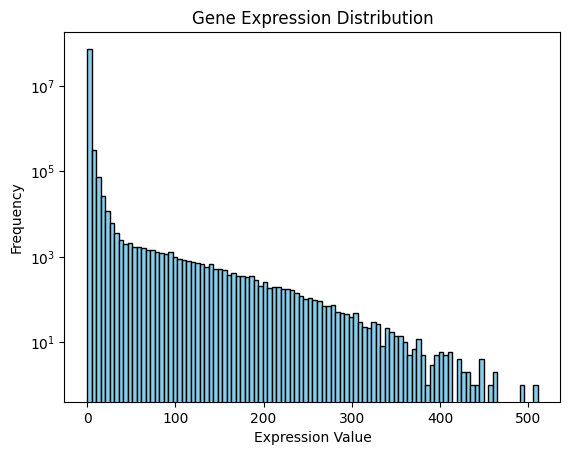

In [ ]:
# 可视化所有表达值的分布（含0）
nonzero_expr = expr[expr >= 0]

plt.hist(nonzero_expr, bins=100, color='skyblue', edgecolor='black')
plt.title("Gene Expression Distribution")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.yscale("log")  # 如表达跨度较大，可使用对数坐标
plt.show()


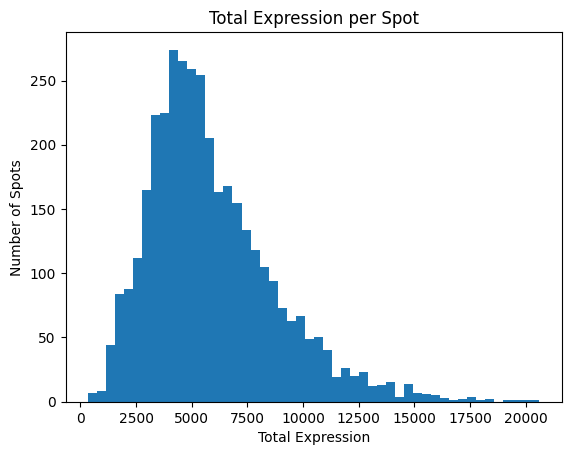

In [8]:
total_per_spot = expr.sum(axis=1)
plt.hist(total_per_spot, bins=50)
plt.title("Total Expression per Spot")
plt.xlabel("Total Expression")
plt.ylabel("Number of Spots")
plt.show()


#### spot的基因表达密度曲线

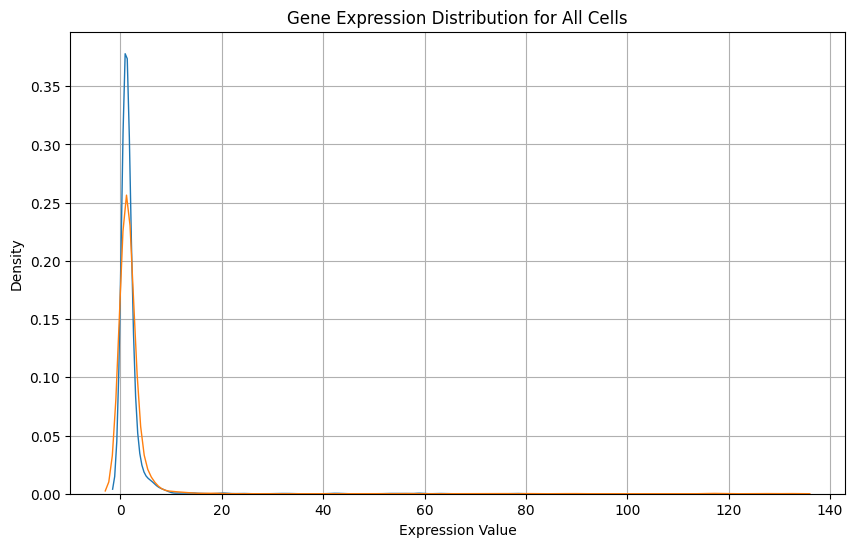

In [18]:
# 开始绘图
plt.figure(figsize=(10, 6))

# === 遍历每个细胞 ===
# for i in range(expr.shape[0]):
#     gene_expr = expr[i]
#     gene_expr = gene_expr[gene_expr > 0]  # 去除零值
#     if len(gene_expr) > 1:  # 确保有足够点进行 KDE
#         sns.kdeplot(gene_expr, color='steelblue', alpha=0.1, linewidth=0.5)

# === 随机20个细胞 ===
np.random.seed(42)  # 可复现
num_cells_to_plot = 2
selected_cells = np.random.choice(expr.shape[0], num_cells_to_plot, replace=False)
for idx in selected_cells:
    cell_expr = expr[idx]
    sns.kdeplot(cell_expr[cell_expr > 0], label=f'Cell {idx}', linewidth=1)

plt.title("Gene Expression Distribution for All Cells")
plt.xlabel("Expression Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()


#### gene表达值分布曲线

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


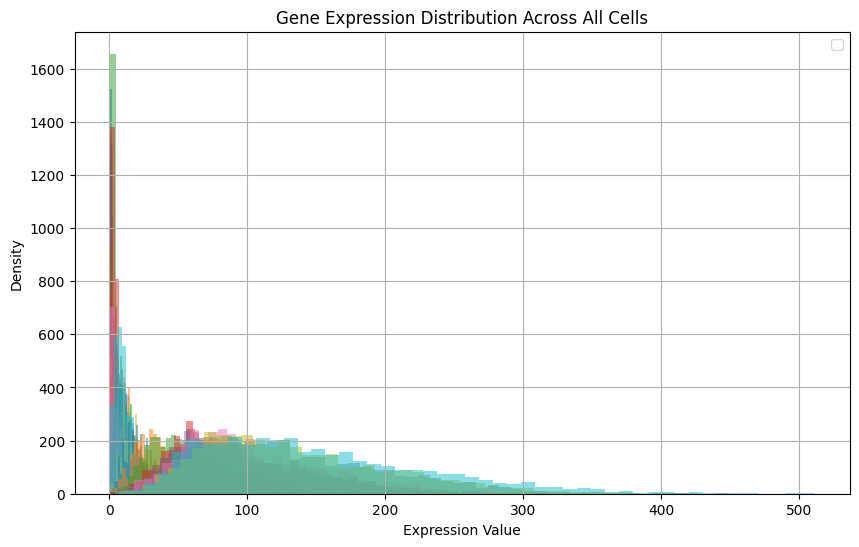

In [31]:
# 获取基因名（如果有）
gene_names = ad_data.var_names if 'var_names' in ad_data.var else [f"Gene_{i}" for i in range(expr.shape[1])]

# 设置要绘制的基因数（可改为任意数量）
num_genes_to_plot = 20000
selected_genes = range(num_genes_to_plot)

# 画图
plt.figure(figsize=(10, 6))

for i in selected_genes:
    gene_expr = expr[:, i]
    gene_expr = gene_expr[gene_expr > 0]  # 可选：去掉表达为 0 的点
    if len(gene_expr) > 1:
        # sns.kdeplot(gene_expr, label=gene_names[i], linewidth=1)
        plt.hist(gene_expr, bins=50, alpha=0.5)

plt.title("Gene Expression Distribution Across All Cells")
plt.xlabel("Expression Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()
